## Exploratory Data Analysis (EDA) Checklist

Task 01 · EDA Checklist on Your Own Data [Medium]

Goal:
Take any CSV or SQLite database from Weeks 1–4 and run every step of the EDA checklist on it.

1. Load the dataset into a Pandas DataFrame —
   use pd.read_csv() or pd.read_sql()

2. Print:
   df.shape, df.info(), df.dtypes —
   document what you find in comments

3. Check for missing values:
   df.isnull().sum() —
   what % is missing per column?

4. Run:
   df.describe() —
   identify 3 observations
   (e.g. mean vs median, suspicious min/max)

5. Run:
   df['col'].value_counts()
   on at least 1 categorical column

6. Plot a histogram for every numeric column —
   do they look normal or skewed?

7. Plot a box plot for at least 2 columns —
   are there outliers?

8. Write a 5-line comment block at the top summarising what you found

Deliverable:
- .py script with all 8 steps
- charts saved as .png

Bonus:
Use sns.pairplot() on all numeric columns and describe.

### 1️⃣ Import Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
from dotenv import load_dotenv
import os

# Create folder for saving charts
os.makedirs("charts", exist_ok=True)

# Optional styling
sns.set_style("whitegrid")

### 2️⃣ Load Environment Variables and 3️⃣ Connect to MySQL Database

In [4]:
load_dotenv()

conn = mysql.connector.connect(
    host=os.getenv("DB_HOST"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database="etl_project"
)

print("Database Connected Successfully")

Database Connected Successfully


### 4️⃣ Read Data from Database Table

In [5]:
query = "SELECT * FROM tvmaze_shows"

df = pd.read_sql(query, conn)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


C:\Users\sumit\AppData\Local\Temp\ipykernel_20944\83655211.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


### 5️⃣ Display First Rows and 6️⃣ Dataset Shape

In [12]:
df.head()


,id,name,language,status,genres,premiered,ended,rating_average,rating_category,summary_word_count,show_duration_years
0,1,Under the Dome,English,Ended,"['Drama', 'Science-Fiction', 'Thriller']",2013-06-24,2015-09-10,6.6,Good,57,2
1,2,Person of Interest,English,Ended,"['Action', 'Crime', 'Science-Fiction']",2011-09-22,2016-06-21,8.8,Excellent,96,5
2,3,Bitten,English,Ended,"['Drama', 'Horror', 'Romance']",2014-01-11,2016-04-15,7.4,Good,75,2
3,4,Arrow,English,Ended,"['Drama', 'Action', 'Science-Fiction']",2012-10-10,2020-01-28,7.4,Good,85,8
4,5,True Detective,English,Running,"['Drama', 'Crime', 'Thriller']",2014-01-12,1-01-01,8.1,Excellent,47,12


In [13]:
print("Shape of Dataset:")
print(df.shape)

Shape of Dataset:
(240, 11)


### Observation:
The dataset contains 240 TV show records and 11 features related to show details such as name, language, genres, ratings, status, premiere date, and duration. Most shows are English-language series, and many belong to multiple genres. The dataset includes both running and ended shows, making it useful for trend and duration analysis. Ratings are categorized into labels such as “Good” and “Excellent,” which can help in comparative analysis. Some preprocessing may be required for date formatting and handling multi-valued genre fields before advanced analysis.

### 7️⃣ Dataset Information and 8️⃣ Data Types

In [15]:
df.info()

print("Types of Data")
print(df.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   240 non-null    int64         
 1   name                 240 non-null    str           
 2   language             240 non-null    str           
 3   status               240 non-null    str           
 4   genres               240 non-null    str           
 5   premiered            240 non-null    datetime64[us]
 6   ended                240 non-null    datetime64[us]
 7   rating_average       240 non-null    float64       
 8   rating_category      240 non-null    str           
 9   summary_word_count   240 non-null    int64         
 10  show_duration_years  240 non-null    int64         
dtypes: datetime64[us](2), float64(1), int64(3), str(5)
memory usage: 20.8 KB
Types of Data
id                              int64
name                              s

### Observation:
The dataset is a structured Pandas DataFrame containing 240 entries and 11 columns with no missing values. It includes multiple data types such as integer, float, string, and datetime. Numerical columns like rating_average, summary_word_count, and show_duration_years can be used for statistical analysis, while categorical columns such as language, status, genres, and rating_category are useful for classification and grouping. The premiered and ended columns are stored in datetime format, enabling time-based analysis. Since the dataset is clean and complete, it is well-suited for exploratory data analysis and visualization.

### 9️⃣ Missing Values Check

In [16]:
missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_df

,Missing Values,Missing Percentage
id,0,0.0
name,0,0.0
language,0,0.0
status,0,0.0
genres,0,0.0
premiered,0,0.0
ended,0,0.0
rating_average,0,0.0
rating_category,0,0.0
summary_word_count,0,0.0


### 🔟 Statistical Summary

In [17]:
df.describe()

,id,premiered,ended,rating_average,summary_word_count,show_duration_years
count,240.000000,240,240,240.000000,240.000000,240.000000
mean,125.429167,2011-01-14 10:42:00,1839-10-09 10:36:00,7.459583,90.550000,6.000000
min,1.000000,1989-03-11 00:00:00,0001-01-01 00:00:00,0.000000,10.000000,0.000000
25%,62.750000,2009-10-01 12:00:00,2014-02-26 00:00:00,7.200000,47.000000,1.000000
50%,126.500000,2012-10-05 00:00:00,2015-05-07 12:00:00,7.600000,74.500000,4.000000
75%,188.250000,2014-02-25 18:00:00,2017-09-22 06:00:00,8.100000,120.250000,8.000000
max,249.000000,2014-11-17 00:00:00,2026-05-15 00:00:00,9.200000,326.000000,37.000000
std,72.408268,NaN,NaN,1.197204,58.941266,6.720356


### Value Counts for Categorical Column

In [18]:
df["status"].value_counts()

status
Ended               219
Running              20
To Be Determined      1
Name: count, dtype: int64

### Histograms for Numeric Columns

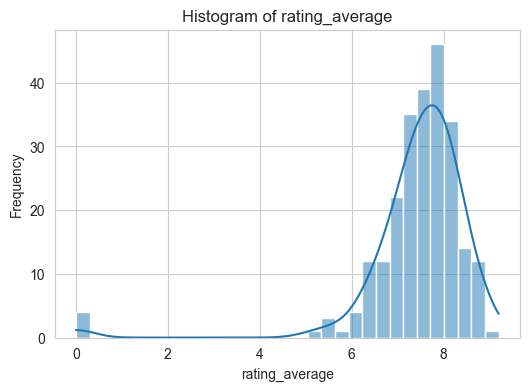

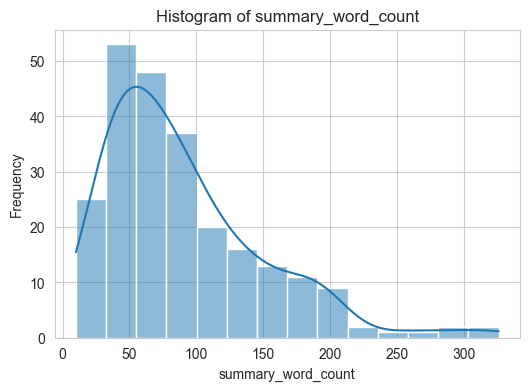

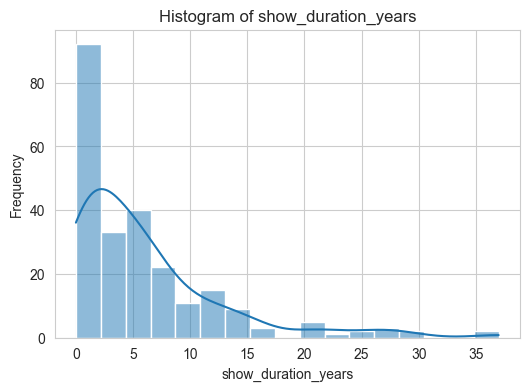

In [20]:
numeric_cols = [
    "rating_average",
    "summary_word_count",
    "show_duration_years"
]

for col in numeric_cols:
    
    plt.figure(figsize=(6,4))
    
    sns.histplot(df[col], kde=True)
    
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    plt.savefig(f"charts/{col}_histogram.png")
    
    plt.show()

### Observations from Histograms

#### 1. `rating_average`

* Most TV shows have ratings between **6 and 8.5**, indicating that the majority of shows are fairly well-rated.
* The distribution is slightly **left-skewed**, with very few shows having extremely low ratings.
* A small number of outliers near **0 rating** may represent missing, unpopular, or incorrectly recorded values.
* The peak around **7.5–8.0** suggests that highly rated shows are common in the dataset.

#### 2. `summary_word_count`

* The distribution is **right-skewed**, meaning most shows have shorter summaries while a few have very long descriptions.
* Most summary lengths fall between **30 and 100 words**.
* A few extreme values above **250 words** act as outliers.
* This indicates that concise summaries are more common than lengthy descriptions.

#### 3. `show_duration_years`

* The distribution is heavily **right-skewed**.
* Most TV shows lasted between **1 and 5 years**, showing that shorter-running series are more common.
* Only a few shows continued for very long durations (20+ years), creating a long tail.
* The presence of extreme durations suggests some classic or highly successful long-running shows.

---

## Overall Summary

> The histograms reveal that most TV shows in the dataset are moderately to highly rated, with ratings concentrated around 7 to 8. Summary lengths are generally short to medium, though a few shows contain very detailed descriptions. Show durations are mostly short-term, as the majority of series run for fewer than 5 years, while only a small number continue for decades. Overall, the dataset demonstrates positively rated content with varying summary lengths and predominantly short-to-medium TV show lifespans.


### Boxplots for Outlier Detection

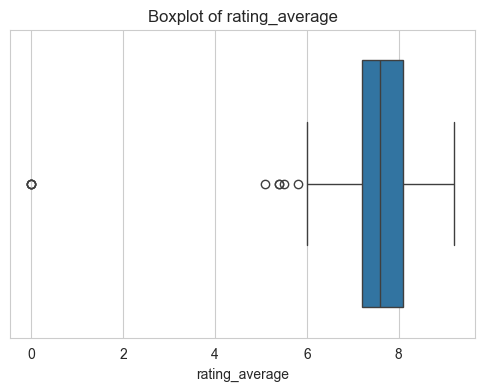

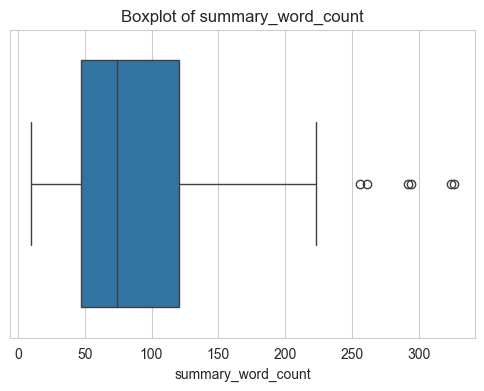

In [21]:
boxplot_cols = [
    "rating_average",
    "summary_word_count"
]

for col in boxplot_cols:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Boxplot of {col}")
    
    plt.savefig(f"charts/{col}_boxplot.png")
    
    plt.show()

### Observations from Boxplots

#### 1. `rating_average`

* Most ratings are concentrated between **7 and 8**, indicating consistently good-rated TV shows.
* The median rating is around **7.5**, showing that half of the shows have ratings above this value.
* A few **low-rating outliers** are visible below 6, including one extreme outlier near 0.
* The spread of the data is relatively small, meaning ratings are fairly consistent across shows.

#### 2. `summary_word_count`

* The median summary length is around **70–80 words**.
* The interquartile range (IQR) suggests that most summaries fall between **40 and 120 words**.
* Several **high-value outliers** above 250 words indicate a few unusually detailed summaries.
* The distribution is positively skewed, as longer summaries occur less frequently.

---

## Summary

> The boxplots show that TV show ratings are generally stable and concentrated within a high-rating range, with only a few low-rated outliers. Summary lengths vary more significantly, with most shows having moderate-length descriptions and a few containing exceptionally long summaries. Overall, the dataset demonstrates consistency in ratings while exhibiting greater variability in textual summary lengths.


## Bonus: Pairplot

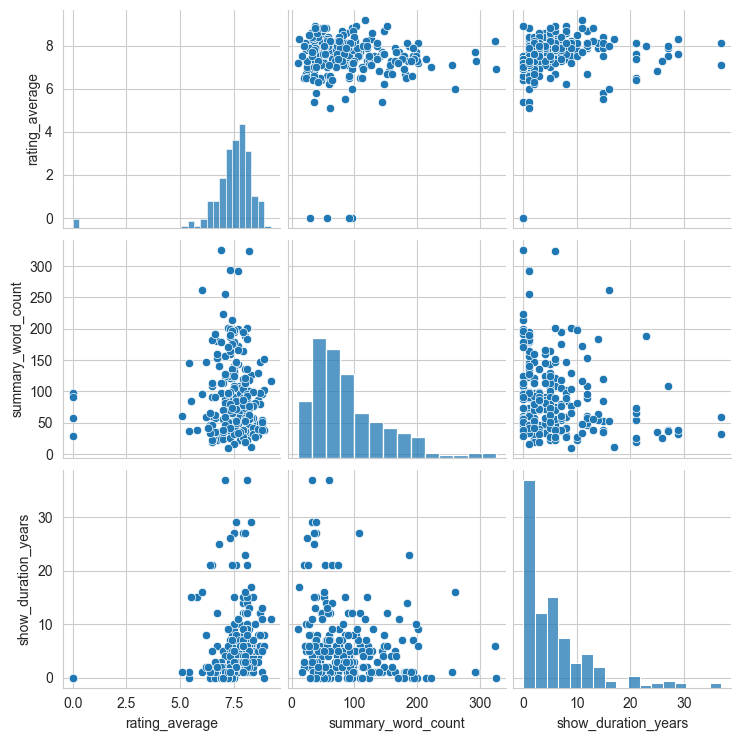

In [22]:
sns.pairplot(df[numeric_cols])

plt.savefig("charts/pairplot.png")

plt.show()

### Observations from Pairplot

#### 1. Distribution of Variables

* `rating_average` is concentrated mostly between **6 and 8.5**, indicating that most TV shows have good ratings.
* `summary_word_count` is right-skewed, with most summaries being relatively short and only a few very long descriptions.
* `show_duration_years` is also right-skewed, as most shows lasted only a few years while a small number continued for decades.

#### 2. Relationship Between `rating_average` and `summary_word_count`

* There is **no strong correlation** between ratings and summary length.
* Both short and long summaries appear across different rating levels.
* Highly rated shows do not necessarily have longer summaries.

#### 3. Relationship Between `rating_average` and `show_duration_years`

* A slight positive trend may exist where some longer-running shows tend to have higher ratings.
* However, the relationship is weak because highly rated shows also exist with shorter durations.

#### 4. Relationship Between `summary_word_count` and `show_duration_years`

* No clear relationship is visible between summary length and show duration.
* Most shows with long durations still have moderate summary lengths.

#### 5. Outliers

* A few outliers are present:

  * Extremely low ratings near 0
  * Very long summaries above 250 words
  * Very long-running shows exceeding 30 years

---

## Summary

> The pairplot reveals that most TV shows in the dataset are well-rated, have moderate summary lengths, and run for relatively short durations. The variables show weak or no strong linear relationships with one another, suggesting that factors such as ratings, summary length, and show duration are largely independent. Several outliers are present, including extremely long-running shows and unusually lengthy summaries.


## Close Database Connection

In [23]:
conn.close()

print("Database Connection Closed")

Database Connection Closed



EDA SUMMARY

1. The dataset contains TV show information collected from the TVMaze API and stored in a MySQL database.
2. Missing values were mainly found in the 'ended' column because many shows are still running.
3. The rating_average column is fairly balanced, while summary_word_count is positively skewed.
4. Boxplots revealed outliers in summary_word_count and show_duration_years, indicating some unusually large values.
5. Most TV shows in the dataset belong to the 'Running' and 'Ended' status categories.
